## Day 2: Zebra Graph

Zebra graphs are discussed in <https://mathworld.wolfram.com/ZebraGraph.html>.

I visualized the geodesic distance from the top-left corner.

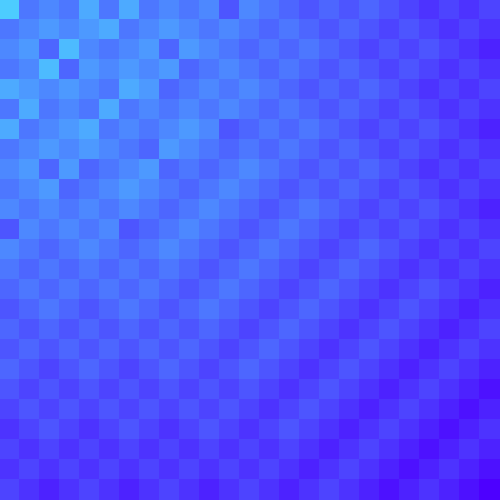

In [1]:
import io
import itertools

import cairo
import IPython.display


svgio = io.BytesIO()
canvas_size = 500

side_count = 25
side_size = canvas_size / side_count


# Calculate the distance across the board
distances = dict[tuple[int, int], int]()


def walk(i: int, j: int, dist: int) -> None:
    if not (0 <= i < side_count) or not (0 <= j < side_count):
        return

    if (existing_dist := distances.get((i, j))) is not None and existing_dist <= dist:
        return

    distances[i, j] = dist

    for sign_i, sign_j in itertools.product([-1, 1], repeat=2):
        walk(i + sign_i * 2, j + sign_j * 3, dist + 1)
        walk(i + sign_i * 3, j + sign_j * 2, dist + 1)


walk(i=0, j=0, dist=0)
max_distance = max(distances.values())


# Draw the board with darker colors indicating a greater distance
with cairo.SVGSurface(svgio, canvas_size, canvas_size) as surface:
    context = cairo.Context(surface)

    for i in range(side_count):
        for j in range(side_count):
            if (i, j) not in distances:
                continue

            context.set_source_rgb(0.3, 0.8 * (1 - distances[i, j] / max_distance), 1)
            context.rectangle(i * side_size, j * side_size, side_size, side_size)
            context.fill_preserve()
            context.stroke()


IPython.display.display(
    IPython.display.SVG(
        svgio.getvalue().decode(),
    ),
)